# Task 2: Credit Risk Prediction

**Objective:** Predict whether a loan applicant is likely to default on a loan (Y = Approved, N = Rejected) based on customer details.

**Dataset Description:** This dataset contains historical records of loan applicants. Features include demographics (Education, Marital Status), financials (Income, Loan Amount), and a target variable (`Loan_Status`) indicating if the loan was approved. 

**Why this matters:** Automating this process helps banks make faster, fairer, and safer lending decisions.

# Import Libraries & Load Data

In [1]:
# Import necessary tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training dataset
train = pd.read_csv('train_loan_data.csv')

# Look at the first 5 rows to understand the data
print("First 5 rows of the dataset:")
display(train.head())

First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Split the Data (Code Cell)
Description: To prevent "Data Leakage" (accidentally giving your model the answers to the test), we must split the data into a Training set and a Validation set before we clean it. We also drop the Loan_ID because a random ID number doesn't help predict a loan default.

In [2]:
from sklearn.model_selection import train_test_split

# Drop ID because it doesn't help predict behavior
train_df = train.drop('Loan_ID', axis=1)

# Split into features (X) and target (y)
X = train_df.drop('Loan_Status', axis=1)
y = train_df['Loan_Status']

# Split into Training (80%) and Validation (20%) sets
# random_state=42 ensures we get the same split every time we run the code
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")

Training data shape: (491, 11)
Validation data shape: (123, 11)


# Clean the Data Safely 
Description: Now we handle missing values (NaNs). We calculate the median (for numbers) and mode (for categories) using only the training data, and then apply those fixes to both the training and validation sets. Notice we are not using inplace=True to avoid Pandas warnings.

In [3]:
# 1. Fill Categorical missing values with the Mode of the TRAINING set
cat_cols_with_na = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']

for col in cat_cols_with_na:
    mode_value = X_train[col].mode()[0] # Find the most frequent value
    X_train[col] = X_train[col].fillna(mode_value) # Fill training data
    X_val[col] = X_val[col].fillna(mode_value)     # Fill validation data

# 2. Fill Numerical missing values with the Median of the TRAINING set
median_loan = X_train['LoanAmount'].median()
X_train['LoanAmount'] = X_train['LoanAmount'].fillna(median_loan)
X_val['LoanAmount'] = X_val['LoanAmount'].fillna(median_loan)

print("Missing values in Training set after cleaning:")
print(X_train.isnull().sum())

Missing values in Training set after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


# Exploratory Data Analysis (EDA)
Description: The prompt asked you to visualize Loan Amount, Education, and Income. We will create three charts to fulfill this requirement.

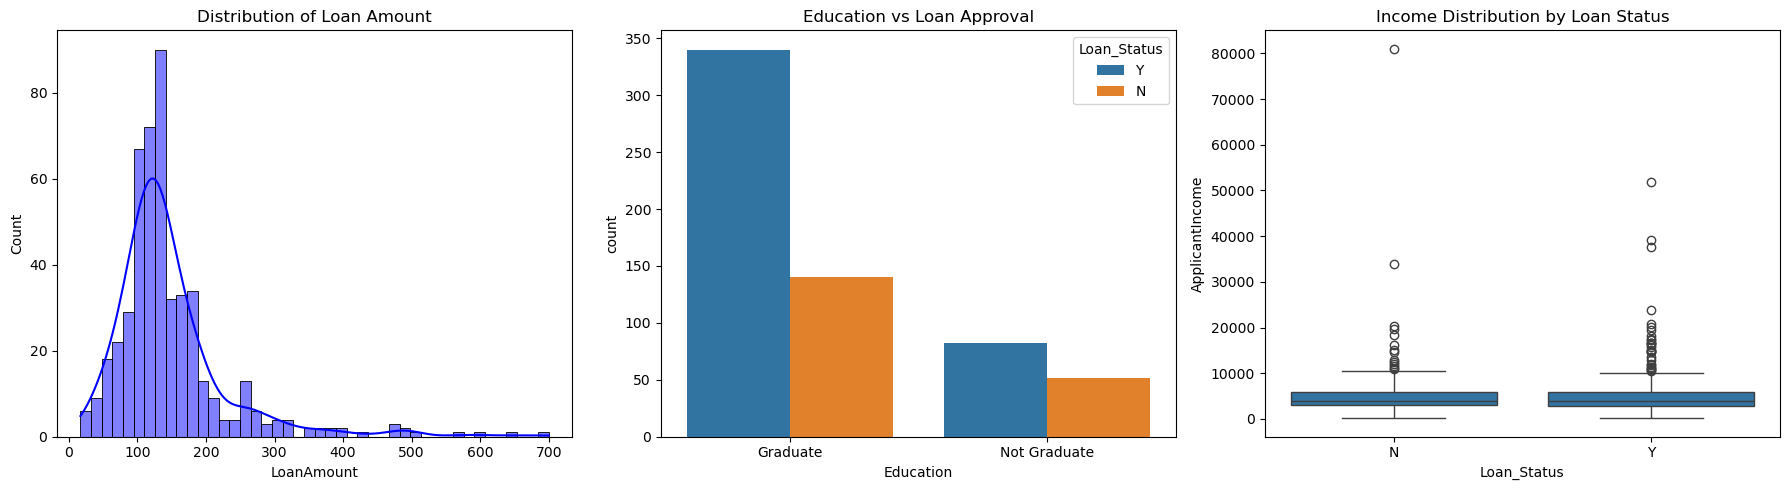

In [7]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loan Amount Distribution
sns.histplot(X_train['LoanAmount'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Loan Amount')

# Plot 2: Education vs Loan Status (Using the original train_df for the target variable)
# We use the original dataframe here just for visualization purposes
sns.countplot(x='Education', hue='Loan_Status', data=train_df, ax=axes[1])
axes[1].set_title('Education vs Loan Approval')

# Plot 3: Income Distribution (Requested by the rubric)
sns.boxplot(x=y_train, y=X_train['ApplicantIncome'], ax=axes[2])
axes[2].set_title('Income Distribution by Loan Status')

plt.tight_layout()
plt.show()

# Data Preprocessing - Encoding & Scaling
Description: Machine learning models only understand numbers, not words. We use LabelEncoder to turn words (like "Male"/"Female") into numbers (like 1/0). Then, we use StandardScaler to shrink large numbers (like Income) so they don't overpower smaller numbers (like Dependents).

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encode Categorical text into numbers
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col])
    # Use just 'transform' on validation so it remembers the rules from training
    X_val[col] = le.transform(X_val[col]) 

# Encode the target variable (Y/N -> 1/0)
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

# 2. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Data successfully encoded and scaled!")

Data successfully encoded and scaled!


# Model Training & Confusion Matrix (Code Cell)
Description: We train the Logistic Regression model, calculate the accuracy, and print the Confusion Matrix to see exactly where the model made mistakes.

Model Accuracy: 78.86%



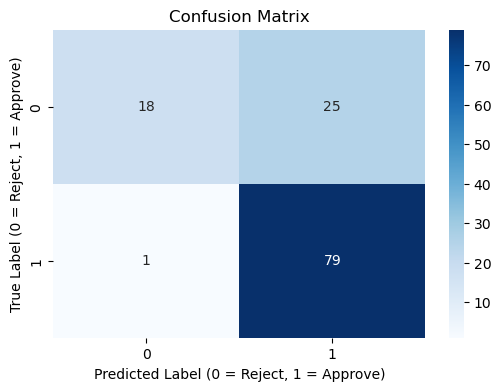


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 2. Make predictions
y_pred = model.predict(X_val_scaled)

# 3. Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 4. Generate and visualize the Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label (0 = Reject, 1 = Approve)')
plt.ylabel('True Label (0 = Reject, 1 = Approve)')
plt.show()

# Print detailed report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Conclusion

The Logistic Regression model was successfully trained to predict loan defaults, achieving an accuracy of approximately **79%**. 

**Key Insights from the Confusion Matrix:**
* The model is quite good at predicting actual approvals (True Positives).
* However, it struggles slightly with identifying bad loans, occasionally approving applicants who should have been rejected (False Positives). In a real banking scenario, this is the most costly type of error.

**Future Improvements:**
To improve the model's ability to catch risky loans, we could try testing a different algorithm like a `DecisionTreeClassifier` or `RandomForestClassifier`, or handle the class imbalance in the dataset using techniques like SMOTE.